In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRICE_SOURCE_TZ = "America/New_York"
ANALYSIS_TZ = "Europe/Amsterdam"

# Load minute data

In [7]:
DATA_DIR = Path("Data/EURUSD 1m")
YEARS_TO_LOAD = range(2009, 2026)

all_price_files = sorted(DATA_DIR.glob("DAT_ASCII_EURUSD_M1_*.csv"))
selected_years = {str(year) for year in YEARS_TO_LOAD}
price_files = [path for path in all_price_files if path.stem.split("_")[-1] in selected_years]

column_names = ["timestamp_raw", "open", "high", "low", "close"]
dtype_map = {
    "open": "float32",
    "high": "float32",
    "low": "float32",
    "close": "float32",
}

frames = []
for price_file in price_files:
    year_df = pd.read_csv(
        price_file,
        sep=";",
        header=None,
        usecols=range(len(column_names)),
        names=column_names,
        dtype=dtype_map,
    )
    year_df["timestamp"] = (
        pd.to_datetime(year_df["timestamp_raw"], format="%Y%m%d %H%M%S", errors="raise")
        .dt.tz_localize(PRICE_SOURCE_TZ)
        .dt.tz_convert(ANALYSIS_TZ)
    )
    frames.append(year_df.drop(columns="timestamp_raw"))

eurusd = (
    pd.concat(frames, ignore_index=True)
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

loaded_years = [path.stem.split("_")[-1] for path in price_files]

print(f"Loaded {len(eurusd):,} rows from {len(price_files)} files.")
print(f"Years loaded: {loaded_years[0]} -> {loaded_years[-1]}")
print(f"Date range: {eurusd['timestamp'].min()} -> {eurusd['timestamp'].max()}")
display(eurusd.head())


Loaded 6,219,282 rows from 17 files.
Years loaded: 2009 -> 2025
Date range: 2009-01-02 00:59:00+01:00 -> 2025-12-31 22:57:00+01:00


,open,high,low,close,timestamp
0,1.4005,1.4005,1.4005,1.4005,2009-01-02 00:59:00+01:00
1,1.4008,1.4008,1.4003,1.4004,2009-01-02 01:00:00+01:00
2,1.4005,1.4009,1.4005,1.4008,2009-01-02 01:01:00+01:00
3,1.4009,1.4011,1.4009,1.4011,2009-01-02 01:02:00+01:00
4,1.4009,1.4009,1.4005,1.4005,2009-01-02 01:03:00+01:00


# Load event data

In [8]:
EVENT_FILES = {
    # "EUR": Path("Data/eur_events_backup.xlsx"),
    "US": Path("Data/us_events_backup.xlsx"),
}

event_frames = []
for region, workbook_path in EVENT_FILES.items():
    workbook = pd.read_excel(
        workbook_path,
        sheet_name=None,
        usecols="A:D",
        engine="openpyxl",
        na_values=["#N/A N/A"],
    )
    for event_name, event_df in workbook.items():
        event_df = event_df.copy()
        event_df.columns = ["date", "survey", "actual", "datetime_raw"]
        event_df["region"] = region
        event_df["event_name"] = event_name
        event_frames.append(event_df)

events = pd.concat(event_frames, ignore_index=True)
events["date"] = pd.to_datetime(events["date"], errors="coerce")
events["datetime_raw"] = pd.to_datetime(events["datetime_raw"], errors="coerce")

events["survey"] = pd.to_numeric(events["survey"], errors="coerce")
events["actual"] = pd.to_numeric(events["actual"], errors="coerce")

event_row_mask = events[["date", "survey", "actual", "datetime_raw"]].notna().any(axis=1)
helper_only_rows_dropped = int((~event_row_mask).sum())
events = events.loc[event_row_mask].copy()

events["datetime"] = (
    events["datetime_raw"]
    .dt.tz_localize(ANALYSIS_TZ, ambiguous="NaT", nonexistent="shift_forward")
)

events = (
    events.sort_values(["datetime", "region", "event_name"], kind="stable")
    .reset_index(drop=True)
)

# Filter for events after 2008
cutoff = pd.Timestamp('2009-01-01', tz=ANALYSIS_TZ)
events = events[events['datetime'] >= cutoff]

print(f"Loaded {len(events):,} event rows from {len(EVENT_FILES)} workbooks.")
print(f"Date range: {events['datetime'].min()} -> {events['datetime'].max()}")
display(events.head())


Loaded 1,032 event rows from 1 workbooks.
Date range: 2009-01-02 16:00:00+01:00 -> 2026-03-18 19:00:00+01:00


,date,survey,actual,datetime_raw,region,event_name,datetime
512,2009-01-02,35.40,32.40,2009-01-02 16:00:00,US,bus_cond,2009-01-02 16:00:00+01:00
513,2009-01-09,-525.00,-524.00,2009-01-09 14:30:00,US,NFP,2009-01-09 14:30:00+01:00
514,2009-01-09,7.00,7.20,2009-01-09 14:30:00,US,unempl_rate,2009-01-09 14:30:00+01:00
515,2009-01-16,-0.20,0.10,2009-01-16 14:30:00,US,cpi_yoy,2009-01-16 14:30:00+01:00
516,2009-01-28,0.25,0.25,2009-01-28 20:15:00,US,cb_target_rate,2009-01-28 20:15:00+01:00


In [9]:
eurusd_ret = eurusd[["timestamp", "close"]].copy()
eurusd_ret["ret_1m"] = np.log(eurusd_ret["close"]).diff()
eurusd_ret = eurusd_ret.dropna(subset=["ret_1m"]).reset_index(drop=True)

display(eurusd_ret.head())

,timestamp,close,ret_1m
0,2009-01-02 01:00:00+01:00,1.4004,-0.000071
1,2009-01-02 01:01:00+01:00,1.4008,0.000286
2,2009-01-02 01:02:00+01:00,1.4011,0.000214
3,2009-01-02 01:03:00+01:00,1.4005,-0.000428
4,2009-01-02 01:04:00+01:00,1.4006,0.000071


In [18]:
events_pre_post = events[["datetime", "region", "event_name", "survey", "actual"]].dropna(subset=["datetime"]).copy()

ret_lookup = (
    eurusd_ret[["timestamp", "ret_1m"]]
    .dropna(subset=["timestamp", "ret_1m"])
    .sort_values("timestamp", kind="stable")
    .groupby("timestamp", as_index=True)["ret_1m"]
    .last()
)

pre_vols = []
post_vols = []

for dt in events_pre_post["datetime"]:
    pre_idx = pd.date_range(end=dt - pd.Timedelta(minutes=1), periods=15, freq="min")
    post_idx = pd.date_range(start=dt, periods=15, freq="min")

    pre_r = ret_lookup.reindex(pre_idx)
    post_r = ret_lookup.reindex(post_idx)

    pre_vols.append(np.nan if pre_r.isna().any() else np.sum(pre_r**2))
    post_vols.append(np.nan if post_r.isna().any() else np.sum(post_r**2))

events_pre_post["rv_pre_15m"] = pre_vols
events_pre_post["rv_post_15m"] = post_vols
events_pre_post["rv_diff_15m"] = events_pre_post["rv_post_15m"] - events_pre_post["rv_pre_15m"]
events_pre_post["log_rv_ratio_15m"] = np.log(events_pre_post["rv_post_15m"]) - np.log(events_pre_post["rv_pre_15m"])

display(events_pre_post.head())

,datetime,region,event_name,survey,actual,rv_pre_15m,rv_post_15m,rv_diff_15m,log_rv_ratio_15m
512,2009-01-02 16:00:00+01:00,US,bus_cond,35.40,32.40,8.727719e-07,0.000005,0.000004,1.759037
513,2009-01-09 14:30:00+01:00,US,NFP,-525.00,-524.00,2.469206e-06,0.000020,0.000018,2.113591
514,2009-01-09 14:30:00+01:00,US,unempl_rate,7.00,7.20,2.469206e-06,0.000020,0.000018,2.113591
515,2009-01-16 14:30:00+01:00,US,cpi_yoy,-0.20,0.10,1.299890e-06,0.000004,0.000002,0.997420
516,2009-01-28 20:15:00+01:00,US,cb_target_rate,0.25,0.25,NaN,0.000030,NaN,NaN


In [11]:
summary_15m = events_pre_post[["rv_pre_15m", "rv_post_15m", "rv_diff_15m", "log_rv_ratio_15m"]].dropna().agg(["count", "mean", "median"])
display(summary_15m)

,rv_pre_15m,rv_post_15m,rv_diff_15m,log_rv_ratio_15m
count,9.930000e+02,993.000000,993.000000,993.000000
mean,7.016186e-07,0.000009,0.000009,2.275417
median,3.675072e-07,0.000004,0.000003,2.311834


In [12]:
by_event_15m = (
    events_pre_post.dropna(subset=["rv_pre_15m", "rv_post_15m"])
    .groupby("event_name")
    .agg(
        n_events=("rv_pre_15m", "size"),
        mean_rv_pre_15m=("rv_pre_15m", "mean"),
        mean_rv_post_15m=("rv_post_15m", "mean"),
        mean_rv_diff_15m=("rv_diff_15m", "mean"),
        mean_log_rv_ratio_15m=("log_rv_ratio_15m", "mean"),
    )
    .sort_values("mean_log_rv_ratio_15m", ascending=False)
)

display(by_event_15m)

,n_events,mean_rv_pre_15m,mean_rv_post_15m,mean_rv_diff_15m,mean_log_rv_ratio_15m
event_name,,,,,
NFP,200,7.837432e-07,0.000014,1.321440e-05,2.908519
unempl_rate,200,7.837432e-07,0.000014,1.321440e-05,2.908519
cb_target_rate,129,9.199061e-07,0.000014,1.267836e-05,2.656758
cpi_yoy,200,6.323753e-07,0.000007,5.973158e-06,2.078452
bus_cond,199,5.256618e-07,0.000002,1.483128e-06,1.347637
gdp,65,5.147752e-07,0.000001,8.061724e-07,1.069069


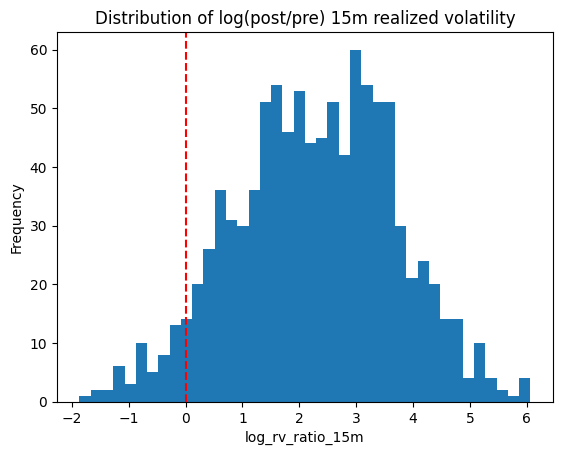

In [13]:
ax = events_pre_post["log_rv_ratio_15m"].dropna().plot(kind="hist", bins=40)
ax.axvline(0, linestyle="--", color="red")
ax.set_title("Distribution of log(post/pre) 15m realized volatility")
ax.set_xlabel("log_rv_ratio_15m")
plt.show()

In [14]:
dist_15m = (
    events_pre_post[["event_name", "rv_pre_15m", "rv_post_15m"]]
    .dropna()
    .melt(
        id_vars="event_name",
        value_vars=["rv_pre_15m", "rv_post_15m"],
        var_name="window_side",
        value_name="rv_15m",
    )
)

display(dist_15m.head())

,event_name,window_side,rv_15m
0,bus_cond,rv_pre_15m,8.727719e-07
1,NFP,rv_pre_15m,2.469206e-06
2,unempl_rate,rv_pre_15m,2.469206e-06
3,cpi_yoy,rv_pre_15m,1.299890e-06
4,bus_cond,rv_pre_15m,1.393300e-06


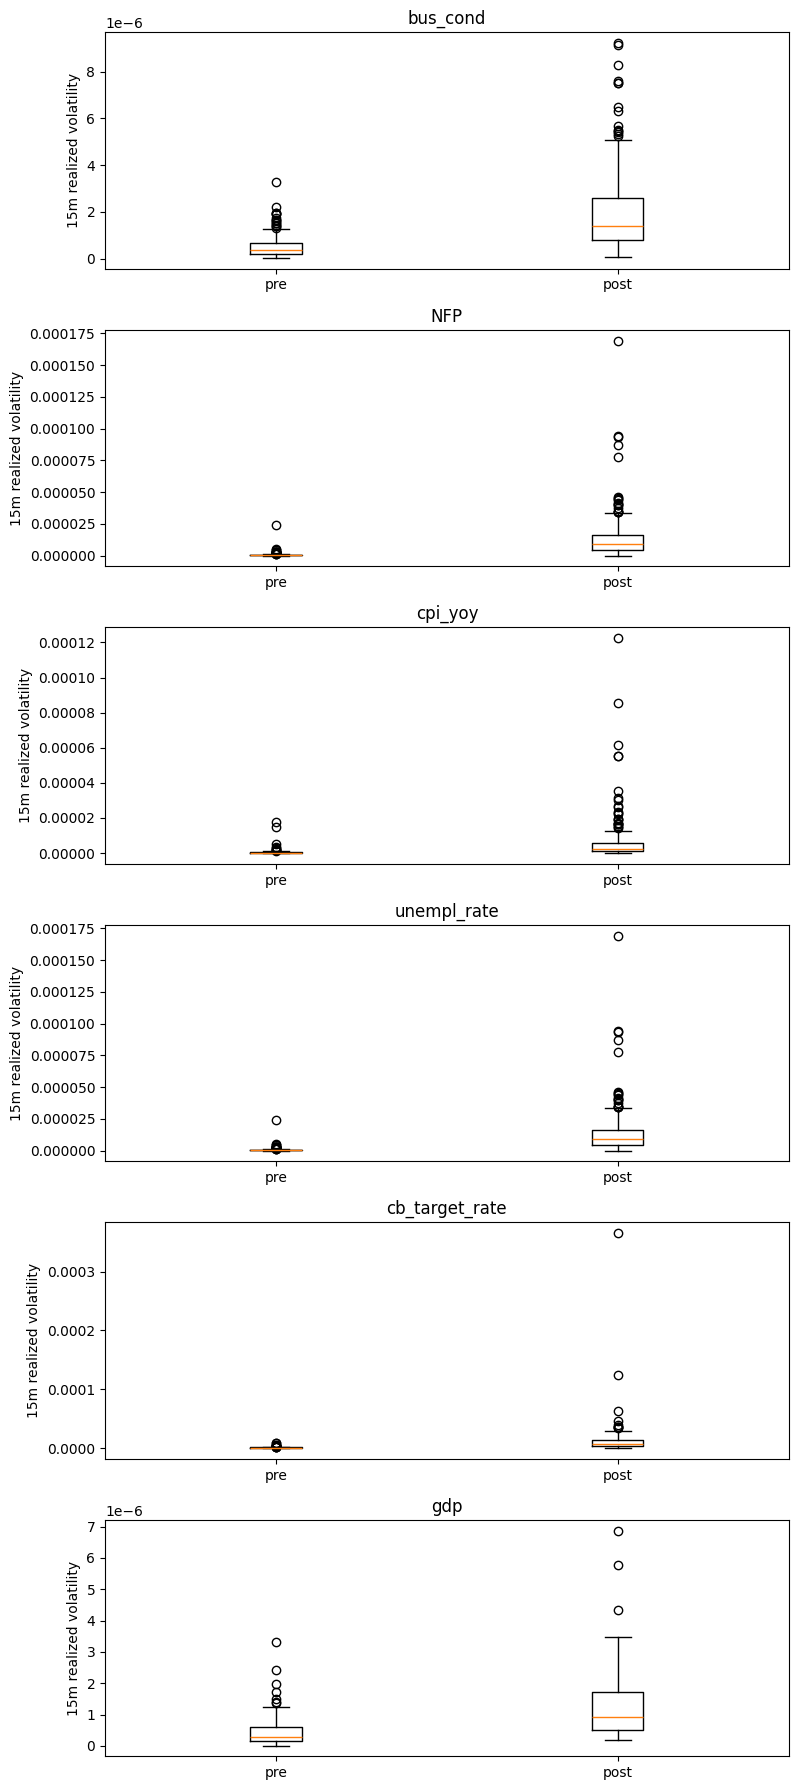

In [15]:
event_order = (
    events_pre_post.groupby("event_name")["rv_pre_15m"]
    .size()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(len(event_order), 1, figsize=(8, 3 * len(event_order)), squeeze=False)

for ax, event_type in zip(axes.ravel(), event_order):
    sub = dist_15m.loc[dist_15m["event_name"] == event_type]
    pre_vals = sub.loc[sub["window_side"] == "rv_pre_15m", "rv_15m"].values
    post_vals = sub.loc[sub["window_side"] == "rv_post_15m", "rv_15m"].values

    ax.boxplot([pre_vals, post_vals], tick_labels=["pre", "post"])
    ax.set_title(str(event_type))
    ax.set_ylabel("15m realized volatility")

plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import ttest_rel, wilcoxon

test_rows = []

for event_type, sub in events_pre_post.groupby("event_name"):
    sub = sub.dropna(subset=["rv_pre_15m", "rv_post_15m", "log_rv_ratio_15m"]).copy()

    if len(sub) < 3:
        test_rows.append({
            "event_name": event_type,
            "n_events": len(sub),
            "mean_rv_pre_15m": sub["rv_pre_15m"].mean(),
            "mean_rv_post_15m": sub["rv_post_15m"].mean(),
            "mean_rv_diff_15m": sub["rv_diff_15m"].mean(),
            "mean_log_rv_ratio_15m": sub["log_rv_ratio_15m"].mean(),
            "ttest_pvalue": np.nan,
            "wilcoxon_pvalue": np.nan,
        })
        continue

    t_res = ttest_rel(sub["rv_post_15m"], sub["rv_pre_15m"], nan_policy="omit")

    try:
        w_res = wilcoxon(sub["rv_post_15m"], sub["rv_pre_15m"])
        w_p = w_res.pvalue
    except ValueError:
        w_p = np.nan

    test_rows.append({
        "event_name": event_type,
        "n_events": len(sub),
        "mean_rv_pre_15m": sub["rv_pre_15m"].mean(),
        "mean_rv_post_15m": sub["rv_post_15m"].mean(),
        "mean_rv_diff_15m": sub["rv_diff_15m"].mean(),
        "mean_log_rv_ratio_15m": sub["log_rv_ratio_15m"].mean(),
        "ttest_pvalue": t_res.pvalue,
        "wilcoxon_pvalue": w_p,
    })

pre_post_tests_15m = pd.DataFrame(test_rows).sort_values("mean_log_rv_ratio_15m", ascending=False)
display(pre_post_tests_15m)

,event_name,n_events,mean_rv_pre_15m,mean_rv_post_15m,mean_rv_diff_15m,mean_log_rv_ratio_15m,ttest_pvalue,wilcoxon_pvalue
0,NFP,200,7.837432e-07,0.000014,1.321440e-05,2.908519,5.183559e-20,4.295042e-34
5,unempl_rate,200,7.837432e-07,0.000014,1.321440e-05,2.908519,5.183559e-20,4.295042e-34
2,cb_target_rate,129,9.199061e-07,0.000014,1.267836e-05,2.656758,4.733569e-05,1.026419e-20
3,cpi_yoy,200,6.323753e-07,0.000007,5.973158e-06,2.078452,1.406355e-09,1.560989e-30
1,bus_cond,199,5.256618e-07,0.000002,1.483128e-06,1.347637,7.033920e-29,7.149793e-32
4,gdp,65,5.147752e-07,0.000001,8.061724e-07,1.069069,3.272662e-06,1.180010e-07


In [17]:
from scipy.stats import ttest_1samp, wilcoxon

logratio_rows = []

for event_type, sub in events_pre_post.groupby("event_name"):
    x = sub["log_rv_ratio_15m"].dropna()

    if len(x) < 3:
        logratio_rows.append({
            "event_name": event_type,
            "n_events": len(x),
            "mean_log_rv_ratio_15m": x.mean() if len(x) else np.nan,
            "median_log_rv_ratio_15m": x.median() if len(x) else np.nan,
            "ttest_logratio_pvalue": np.nan,
            "wilcoxon_logratio_pvalue": np.nan,
        })
        continue

    t_res = ttest_1samp(x, popmean=0, nan_policy="omit")

    try:
        w_res = wilcoxon(x)
        w_p = w_res.pvalue
    except ValueError:
        w_p = np.nan

    logratio_rows.append({
        "event_name": event_type,
        "n_events": len(x),
        "mean_log_rv_ratio_15m": x.mean(),
        "median_log_rv_ratio_15m": x.median(),
        "ttest_logratio_pvalue": t_res.pvalue,
        "wilcoxon_logratio_pvalue": w_p,
    })

logratio_tests_15m = pd.DataFrame(logratio_rows).sort_values("mean_log_rv_ratio_15m", ascending=False)
display(logratio_tests_15m)

,event_name,n_events,mean_log_rv_ratio_15m,median_log_rv_ratio_15m,ttest_logratio_pvalue,wilcoxon_logratio_pvalue
0,NFP,200,2.908519,2.984107,6.518524e-87,2.289052e-34
5,unempl_rate,200,2.908519,2.984107,6.518524e-87,2.289052e-34
2,cb_target_rate,129,2.656758,2.958779,1.164187e-40,1.426393e-21
3,cpi_yoy,200,2.078452,2.072293,6.957291e-48,2.390093e-31
1,bus_cond,199,1.347637,1.389688,1.135997e-56,7.587012e-33
4,gdp,65,1.069069,0.973703,5.208067e-11,7.178873e-09
